C:\Users\mygam\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Libraries Imported. Environment Ready.
✅ Data Loaded: 7909 images with 2048 dimensions.
Processing: Running UMAP Projection (This may take a moment)...


C:\Users\mygam\AppData\Roaming\Python\Python313\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


✅ UMAP Complete.
Processing: Running HDBSCAN Clustering...
✅ Audit Complete.
   - Morphological Families Found: 65
   - Ambiguous 'Noise' Images: 3784 (47.8%)


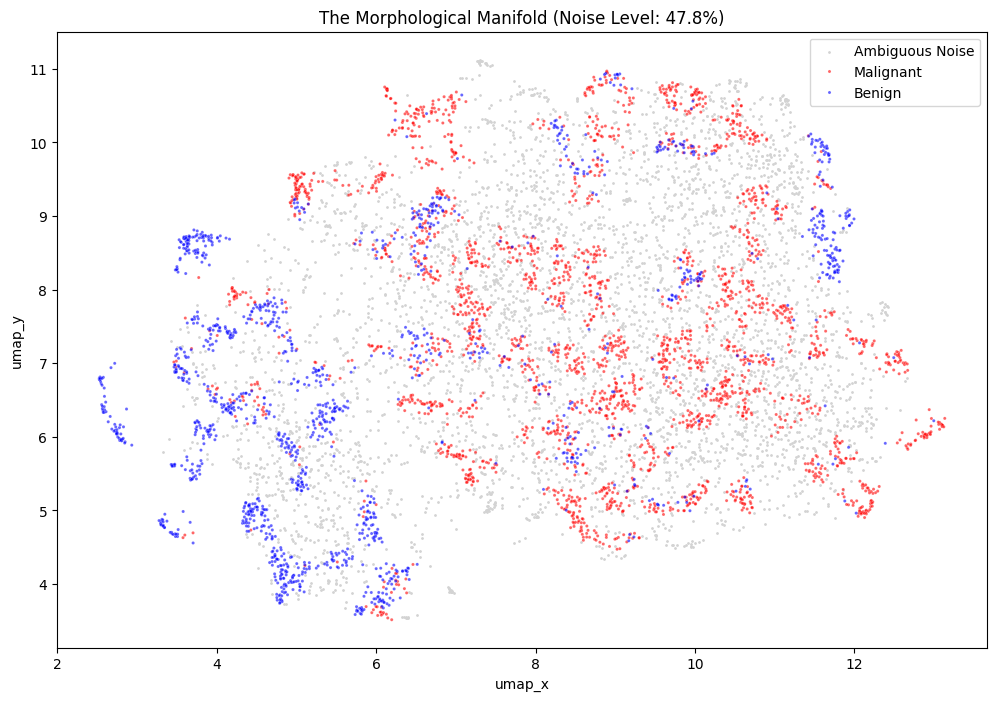


Running Validation: Logistic Regression Stress Test...
✅ Validation Results:
   - Global Accuracy: 0.9437
   - Total Errors: 89
   - Errors inside 'Noise' regions: 50
   - % of Errors explained by Manifold Audit: 56.2%

✅ Pipeline Complete. Audited data saved to ..\results\breakhis_manifold_audited.csv


In [1]:
"""
PROJECT: The Pathologist Uncertainty Auditor
AUTHOR: Davis Whaley
DESCRIPTION: 
This notebook performs an unsupervised audit of the BreaKHis breast cancer dataset.
It uses ResNet50 for feature extraction, UMAP for manifold projection, and 
HDBSCAN to identify "Ambiguous" morphological clusters.
"""

# --- 1. IMPORTS & SETUP ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import umap
import hdbscan
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Configure Paths
PROJECT_ROOT = Path("../") # Pointing up from notebooks folder
DATA_DIR = PROJECT_ROOT / "data" / "processed"
RESULTS_DIR = PROJECT_ROOT / "results"

print("✅ Libraries Imported. Environment Ready.")

# --- 2. DATA LOADING ---
# We load the features we pre-computed (to save 45 mins of GPU time)
# If you are running this from scratch, refer to 'src/feature_extraction.py'
try:
    df = pd.read_csv(DATA_DIR / "breakhis_metadata.csv")
    features = np.load(DATA_DIR / "resnet50_features.npy")
    print(f"✅ Data Loaded: {len(df)} images with {features.shape[1]} dimensions.")
except FileNotFoundError:
    print("❌ Critical Error: Processed data not found. Please ensure feature extraction was run.")

# --- 3. MANIFOLD PROJECTION (UMAP) ---
# We project the 2048D feature space down to 2D to visualize the "Morphological Manifold"
print("Processing: Running UMAP Projection (This may take a moment)...")
reducer = umap.UMAP(
    n_neighbors=15,    # Focus on local texture similarity
    min_dist=0.1,      # Allow tight clustering
    n_components=2,
    metric='euclidean',
    random_state=42
)
embedding = reducer.fit_transform(features)

# Store results
df['umap_x'] = embedding[:, 0]
df['umap_y'] = embedding[:, 1]
print("✅ UMAP Complete.")

# --- 4. THE UNCERTAINTY AUDIT (HDBSCAN) ---
# We use density clustering to find "Natural Families" and "Noise"
print("Processing: Running HDBSCAN Clustering...")
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=30, 
    min_samples=10,
    cluster_selection_method='leaf'
)
df['cluster_id'] = clusterer.fit_predict(embedding)

# Calculate Stats
n_noise = (df['cluster_id'] == -1).sum()
pct_noise = (n_noise / len(df)) * 100
print(f"✅ Audit Complete.")
print(f"   - Morphological Families Found: {df['cluster_id'].max() + 1}")
print(f"   - Ambiguous 'Noise' Images: {n_noise} ({pct_noise:.1f}%)")

# --- 5. VISUALIZATION (The Conflict Map) ---
plt.figure(figsize=(12, 8))
# Plot Noise first (Grey)
noise_data = df[df['cluster_id'] == -1]
plt.scatter(noise_data['umap_x'], noise_data['umap_y'], c='lightgrey', s=1, label='Ambiguous Noise')

# Plot Clusters (Colored by Diagnosis)
labeled_data = df[df['cluster_id'] != -1]
sns.scatterplot(
    data=labeled_data, x='umap_x', y='umap_y', 
    hue='label', palette={'Benign': 'blue', 'Malignant': 'red'}, s=5, alpha=0.6
)
plt.title(f"The Morphological Manifold (Noise Level: {pct_noise:.1f}%)")
plt.legend(loc='upper right')
plt.show()

# --- 6. VALIDATION (The Supervised Stress Test) ---
# We train a classifier to prove that 'Noise' is actually hard to classify
print("\nRunning Validation: Logistic Regression Stress Test...")
X = features
y = df['label']

X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, df.index, test_size=0.2, random_state=42, stratify=y
)

clf = LogisticRegression(max_iter=1000, solver='lbfgs')
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

# Analysis of Errors
test_df = df.loc[idx_test].copy()
test_df['pred'] = y_pred
test_df['correct'] = (test_df['label'] == test_df['pred'])

errors = test_df[~test_df['correct']]
errors_in_noise = errors[errors['cluster_id'] == -1]

print(f"✅ Validation Results:")
print(f"   - Global Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"   - Total Errors: {len(errors)}")
print(f"   - Errors inside 'Noise' regions: {len(errors_in_noise)}")
print(f"   - % of Errors explained by Manifold Audit: {(len(errors_in_noise)/len(errors))*100:.1f}%")

# --- 7. SAVE FINAL ARTIFACTS ---
# Save the audited dataframe for the Dashboard
output_path = RESULTS_DIR / "breakhis_manifold_audited.csv"
df.to_csv(output_path, index=False)
print(f"\n✅ Pipeline Complete. Audited data saved to {output_path}")